In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from arch import arch_model

In [2]:
from warnings import filterwarnings
filterwarnings("ignore")

1. Прочитайте исходный файл с данными. Визуализируйте исходный временной ряд, сделайте первичные выводы о присутствии компонент тренда и сезонности в ряде.

Отложите последние три года из датасета как тестовую выборку для оценки результатов предсказания.

In [3]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\ghana_gdp.csv', parse_dates=['year'], index_col=['year'])
df.head()

,GDP (current US$)
year,
1960-01-01,1.217087e+09
1961-01-01,0.000000e+00
1962-01-01,1.382353e+09
1963-01-01,1.540616e+09
1964-01-01,1.731092e+09


In [4]:
df.isnull().sum().sum()
# Пропусков нет

0

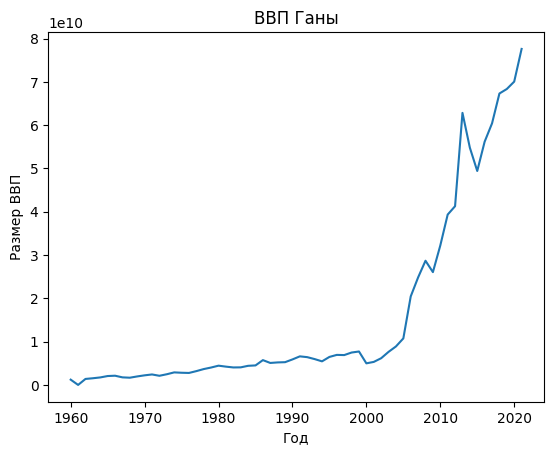

In [5]:
plt.plot(df)
plt.ylabel('Размер ВВП')
plt.xlabel('Год')
plt.title('ВВП Ганы');

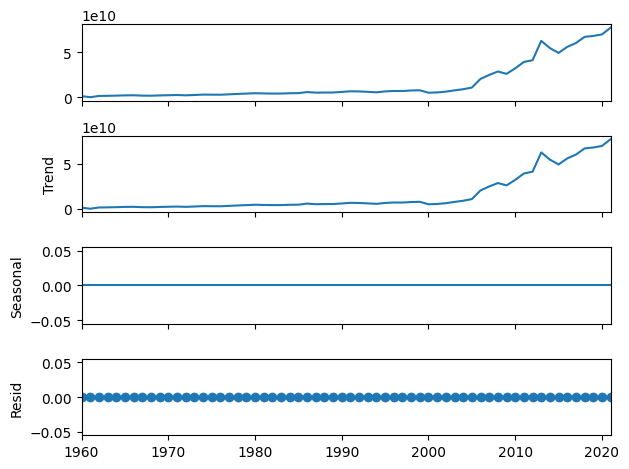

In [6]:
result = seasonal_decompose(df)
result.plot()
plt.show()

In [7]:
X_train = df.iloc[:-3]
X_test = df.iloc[-3:]

По графику ВВП Ганы видно, что с 1960 по 2000 год экономика страны росла крайне низкими темпами, однако после 2000 годов рост стал очень стремительным и за последние 20 лет экономика увеличилась примерно в 10 раз. Ни сезонности, ни тренда на данном графике не наблюдается.
_______________________________________________________________________________________________

2. Постройте график скользящего среднего, проанализируйте результат. Для построения MA используйте метод rolling(), который принимает в качестве параметра размер окна. Используйте среднее как функцию для сглаживания. Ширину окна подберите самостоятельно.
Пример: train_df.spx.rolling(window=2).mean().

Визуализируйте исходный временной ряд и построенный с помощью скользящего среднего прогноз, сравните графики между собой и сделайте выводы.


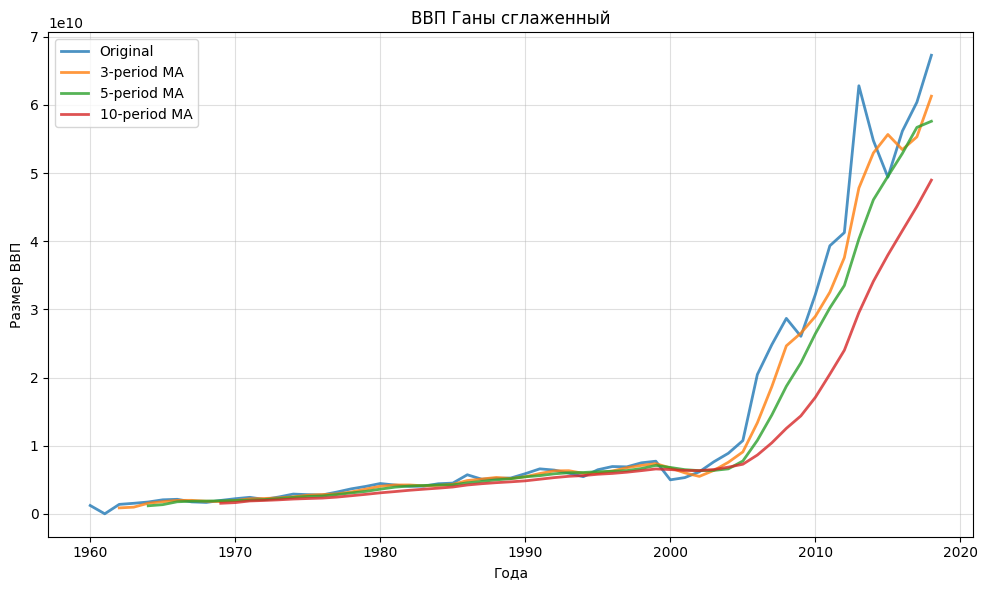

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(X_train.index, X_train['GDP (current US$)'], 
         linewidth=2, label='Original', alpha=0.8)
plt.plot(X_train.index, X_train['GDP (current US$)'].rolling(3).mean(), 
         linewidth=2, label='3-period MA', alpha=0.8)
plt.plot(X_train.index, X_train['GDP (current US$)'].rolling(5).mean(), 
         linewidth=2, label='5-period MA', alpha=0.8)
plt.plot(X_train.index, X_train['GDP (current US$)'].rolling(10).mean(), 
         linewidth=2, label='10-period MA', alpha=0.8)
plt.ylabel('Размер ВВП')
plt.xlabel('Года')
plt.title('ВВП Ганы сглаженный')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.legend();

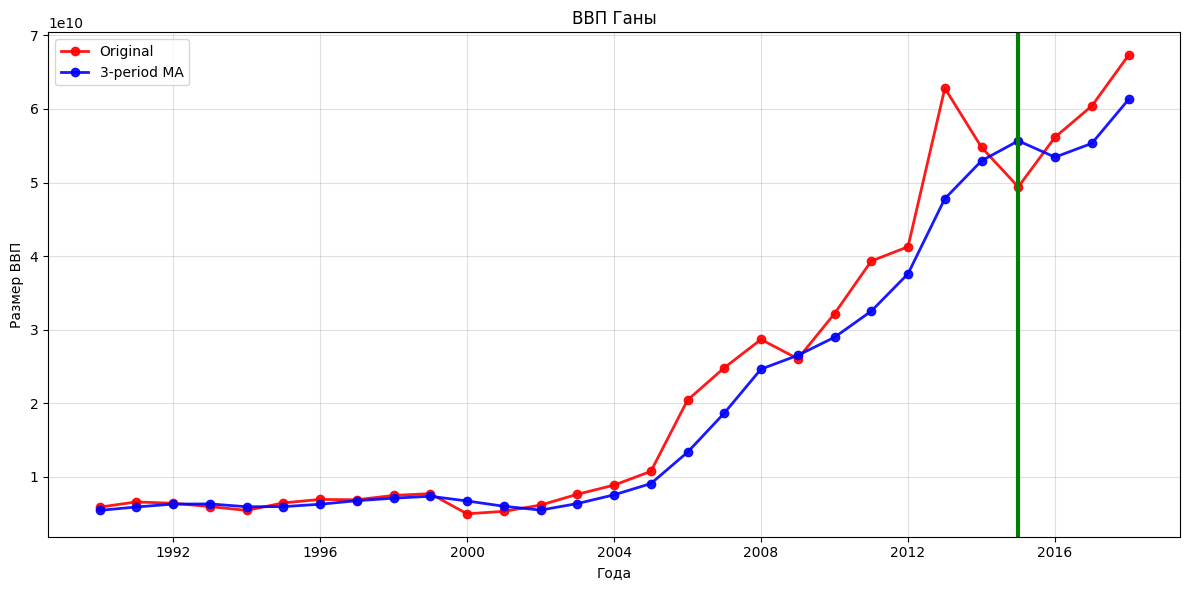

In [9]:
train = X_train['GDP (current US$)']
train_moving_3 = X_train['GDP (current US$)'].rolling(3).mean()
plt.figure(figsize=(12, 6))
plt.plot(train[30:], color='red', marker='o', alpha=0.9, linewidth=2, label='Original')
plt.plot(train_moving_3[30:], color='blue', marker='o', alpha=0.9, linewidth=2, label='3-period MA')
plt.axvline(x=['2015-01-01'], linewidth=3, color='green')
plt.ylabel('Размер ВВП')
plt.xlabel('Года')
plt.title('ВВП Ганы')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.legend();

Скользящее среднее можно использовать только как ориентир, так как SMA не имеет прогностической силы и только сглаживает предыдущие значения временного ряда.
________________________________________________________________________________________________

3. С помощью теста Дики-Фуллера оцените стационарность временного ряда и примите решение о выборе модели ARMA/ARIMA.
Примечание. Если ваш ряд является нестационарным, дифференцируйте его до тех пор, пока он не станет таковым. Количество дифференцирований, необходимых для сведения ряда к стационарному, будет вашим параметром d для модели ARIMA.

Параметры p и q выберите по коррелограммам ACF и PACF.
Примечание. Помните, что параметры p и q для ARMA/ARIMA определяются из коррелограмм стационарного ряда. То есть, если ваш изначальный временной ряд не являлся стационарным, то коррелограммы строятся для разностей того порядка, которые являются стационарными.

Постройте модель ARMA/ARIMA для прогнозирования поведения временного ряда.

Также постройте несколько моделей с параметрами, ближайшими к найденным p и q, и сравните коэффициент AIC (или подберите наилучшие параметры с помощью пакета pmdarima, как в скринкасте).

Тест Дикки-Фулера

In [10]:
result = adfuller(X_train)
print(f'adf: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Критические значения: {result[4]}')
if result[0] > result[4]['5%']:
    print('\nРяд нестационарный')
else:
    print('\nРяд стационарный')

adf: 0.652906697488536
p-value: 0.9888496277665572
Критические значения: {'1%': -3.5745892596209488, '5%': -2.9239543084490744, '10%': -2.6000391840277777}

Ряд нестационарный


In [11]:
X_train_diff = X_train.diff(2).dropna()
result = adfuller(X_train_diff)
print(f'adf: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Критические значения: {result[4]}')
if result[0] > result[4]['5%']:
    print('\nРяд нестационарный')
else:
    print('\nРяд стационарный')

adf: -3.583670865826034
p-value: 0.0060809897538768466
Критические значения: {'1%': -3.584828853223594, '5%': -2.9282991495198907, '10%': -2.6023438271604937}

Ряд стационарный


Чтобы привести ряд к стационарности потребовалось 2 раза дифференцировать данные.
Необходимо использовать модель ARIMA с d=2.

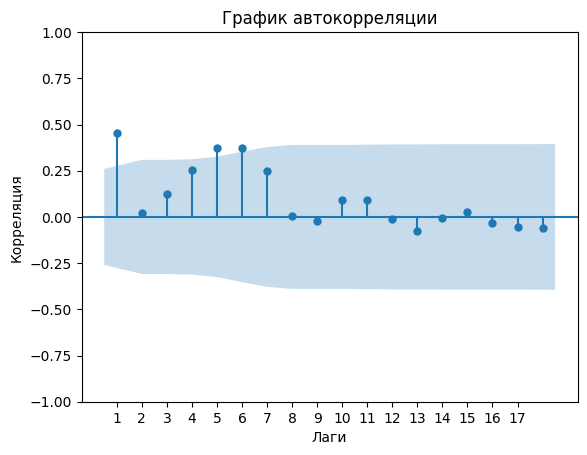

In [12]:
sgt.plot_acf(X_train_diff, zero=False)
plt.title('График автокорреляции')
plt.xlabel('Лаги')
plt.ylabel('Корреляция')
plt.xticks(range(1, 18))
plt.show()

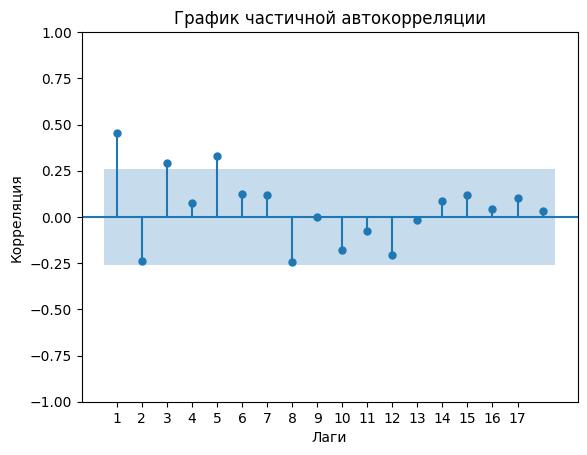

In [13]:
sgt.plot_pacf(X_train_diff, zero=False)
plt.title('График частичной автокорреляции')
plt.xlabel('Лаги')
plt.ylabel('Корреляция')
plt.xticks(range(1, 18))
plt.show()

Исходя из построенных графиков -> p=1, q=1

Построение модели ARIMA(1, 2, 1)

In [14]:
arima_model = ARIMA(X_train, order=(1, 2, 1))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1339.208
Date:                Thu, 19 Feb 2026   AIC                           2684.416
Time:                        18:07:11   BIC                           2690.545
Sample:                    01-01-1960   HQIC                          2686.798
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1775      0.082     -2.159      0.031      -0.339      -0.016
ma.L1         -0.8688      0.046    -19.069      0.000      -0.958      -0.780
sigma2       1.96e+19   2.13e-22    9.2e+40      0.000    1.96e+19    1.96e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):               276.42
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):             325.65   Skew:                             1.34
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number    inf. Standard errors may be unstable.
"""

Выводы:
1) ar.L1 значим, так как 0.031 < 0.05
2) ma.L1 значим, так как 0.000 < 0.05
3) Prob(Q) = 0.68, означает, что автокорреляции в остатках нет
4) Prob(JB) = 0.00, означает, что остатки ненормальны, что не очень хорошо.

In [15]:
smodel = pm.auto_arima(X_train, start_p=1, max_p=5,
                                start_q=1, max_q=5, d=2,
                                test="adf", error_action="ignore", 
                                trace=True, seasonal=False)
smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=2687.339, Time=0.02 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=2721.886, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=2706.594, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=2687.662, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=2719.959, Time=0.01 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=2686.054, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=2694.896, Time=0.01 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=2687.799, Time=0.03 sec
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=2695.926, Time=0.02 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=2683.782, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=2684.416, Time=0.01 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=2693.0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(1, 2, 3)   Log Likelihood               -1335.382
Date:                Thu, 19 Feb 2026   AIC                           2680.765
Time:                        18:07:12   BIC                           2690.980
Sample:                    01-01-1960   HQIC                          2684.735
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5682      0.163     -3.487      0.000      -0.888      -0.249
ma.L1         -0.4241      0.235     -1.803      0.071      -0.885       0.037
ma.L2         -0.8256      0.169     -4.886      0.000      -1.157      -0.494
ma.L3          0.5193      0.137      3.790      0.000       0.251       0.788
sigma2      1.868e+19   8.55e-21   2.18e+39      0.000    1.87e+19    1.87e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               173.00
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):             141.34   Skew:                             1.18
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.15e+55. Standard errors may be unstable.
"""

Выводы:
1) ar.L1 значим, так как 0.000 < 0.05
2) ma.L1 незначим, так как 0.071 > 0.05
3) ma.L2 значим, так как 0.000 < 0.05
4) ma.L3 значим, так как 0.000 < 0.05
5) Prob(Q) = 0.98, означает, что автокорреляции в остатках нет
6) Prob(JB) = 0.00, означает, что остатки ненормальны, что не очень хорошо.
Лучшая модель ARIMA(1, 2, 3) обладает неплохимы статистическими показателями, однако существуют проблемы в виде 1 незначимого коэффициента и ненормальности остатков.
___________________________________________________________________________________________________________________________________________

4. Постройте модель с наилучшими параметрами и выполните предсказание для отложенной тестовой выборки (последние три года).
5. Отобразите результат графически — постройте графики истинного и предсказанного поведения временного ряда, а также 95%-ый доверительный интервал для прогноза.

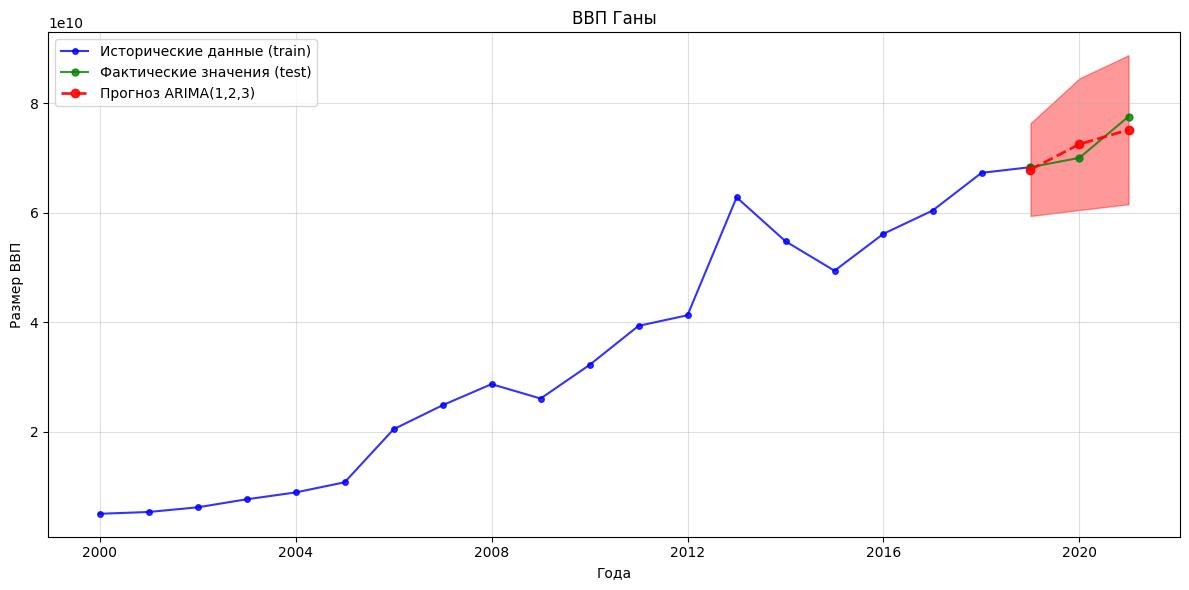

In [16]:
arima_model = ARIMA(X_train, order=(1, 2, 3))
arima_model_fit = arima_model.fit()
Forecast_result = arima_model_fit.get_forecast(steps=len(X_test))
Forecast = Forecast_result.predicted_mean
Forecast_interval = Forecast_result.conf_int(alpha=0.05)
plt.figure(figsize=(12, 6))
plt.plot(df[40:-2], color='blue', marker='o', linestyle='-', 
         linewidth=1.5, markersize=4, label='Исторические данные (train)', alpha=0.8)

plt.plot(X_test, color='green', marker='o', linestyle='-', 
         linewidth=1.5, markersize=5, label='Фактические значения (test)', alpha=0.8)

plt.plot(Forecast, color='red', marker='o', linestyle='--', 
         linewidth=2, markersize=6, label='Прогноз ARIMA(1,2,3)', alpha=0.9)

plt.fill_between(x=Forecast.index, y1=Forecast_interval.iloc[:, 0],
                                   y2=Forecast_interval.iloc[:, 1],
                                   alpha=0.4, color='red')
plt.ylabel('Размер ВВП')
plt.xlabel('Года')
plt.title('ВВП Ганы')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.legend();

По графику видно, что модель неплохо смогла предсказать данные на тестовой выборке.
Если же говорить про доверительный интервал, то он получился достаточно большим, что позволяет спрогнозировать самые различные ситуации в экономике африканского государства.

Часть 2

1. Проверьте данные на наличие пропущенных дат. Помимо визуального способа, это можно сделать с помощью метода DataFrame.asfreq(), передав в него параметр частоты, например ‘d’ — день, ‘m’ — месяц. Все алиасы для параметров частоты доступны по ссылке.

In [17]:
df_check = df.asfreq(freq='YS')
print(f'Размер исходного датасета: {df.shape}')
print(f'Размер проверенного датасета: {df_check.shape}')

Размер исходного датасета: (62, 1)
Размер проверенного датасета: (62, 1)


2. Проверьте данные на наличие пропущенных значений (Series.isna().sum()).

In [18]:
df.isnull().sum()

GDP (current US$)    0
dtype: int64

Пропущенных годов и значений в данных нет

3. Обратите внимание, что иногда пропуски в данных могут быть заполнены нулями. Сделайте проверку на наличие нулевых значений и в случае нахождения замените их на NaN.

In [19]:
df['GDP (current US$)'] = df['GDP (current US$)'].apply(lambda x: np.nan if x == 0 else x)
df.isnull().sum()

GDP (current US$)    1
dtype: int64

4. Для заполнения пропусков выполните интерполяцию с использованием метода .interpolate().

In [20]:
df['GDP (current US$)'] = df['GDP (current US$)'].interpolate('linear')

5. Проверьте полученный ряд на стационарность, определите параметры модели (ARIMA/ARMA) и запустите модель.
6. Изменился ли AIC критерий построенной модели по сравнению с моделью на неинтерполированных данных? Сделайте вывод.

In [21]:
X_train = df.iloc[:-3]
X_test = df.iloc[-3:]

In [22]:
result = adfuller(X_train)
print(f'adf: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Критические значения: {result[4]}')
if result[0] > result[4]['5%']:
    print('\nРяд нестационарный')
else:
    print('\nРяд стационарный')

adf: 0.8030073326980126
p-value: 0.9916845572455877
Критические значения: {'1%': -3.5745892596209488, '5%': -2.9239543084490744, '10%': -2.6000391840277777}

Ряд нестационарный


In [23]:
X_train_diff = X_train.diff(2).dropna()
result = adfuller(X_train_diff)
print(f'adf: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Критические значения: {result[4]}')
if result[0] > result[4]['5%']:
    print('\nРяд нестационарный')
else:
    print('\nРяд стационарный')

adf: -3.9998034409491523
p-value: 0.0014115408436661087
Критические значения: {'1%': -3.584828853223594, '5%': -2.9282991495198907, '10%': -2.6023438271604937}

Ряд стационарный


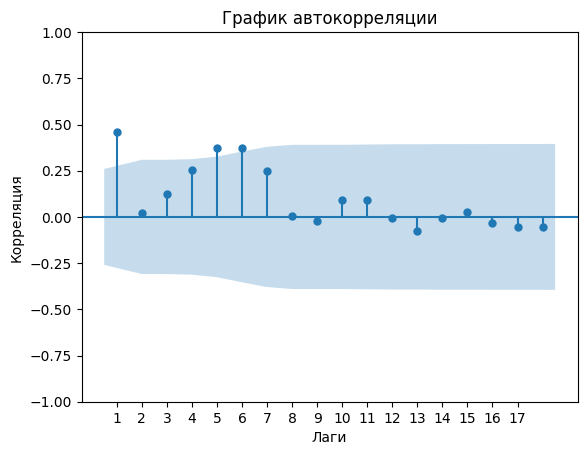

In [24]:
sgt.plot_acf(X_train_diff, zero=False)
plt.title('График автокорреляции')
plt.xlabel('Лаги')
plt.ylabel('Корреляция')
plt.xticks(range(1, 18))
plt.show()

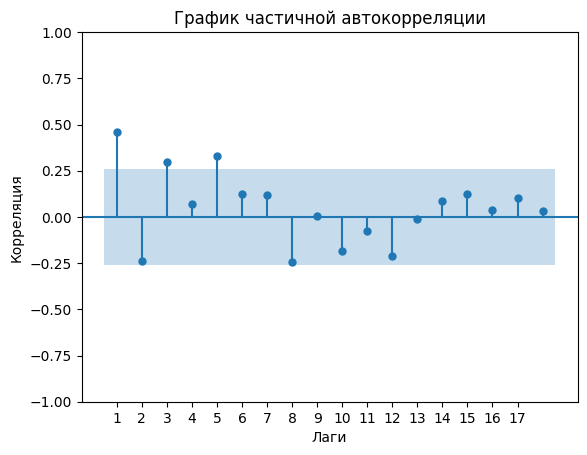

In [25]:
sgt.plot_pacf(X_train_diff, zero=False)
plt.title('График частичной автокорреляции')
plt.xlabel('Лаги')
plt.ylabel('Корреляция')
plt.xticks(range(1, 18))
plt.show()

Графики практически не изменились

In [26]:
smodel = pm.auto_arima(X_train, start_p=1, max_p=5,
                                start_q=1, max_q=5, d=2,
                                test="adf", error_action="ignore", 
                                trace=True, seasonal=False)
smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=2687.479, Time=0.03 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=2721.621, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=2706.528, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=2687.799, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=2719.683, Time=0.01 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=2686.221, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=2694.822, Time=0.01 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=2687.929, Time=0.03 sec
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=2695.861, Time=0.02 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=2683.709, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=2684.377, Time=0.01 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=2692.9

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(1, 2, 3)   Log Likelihood               -1335.257
Date:                Thu, 19 Feb 2026   AIC                           2680.513
Time:                        18:07:13   BIC                           2690.729
Sample:                    01-01-1960   HQIC                          2684.483
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5586      0.171     -3.271      0.001      -0.893      -0.224
ma.L1         -0.4271      0.248     -1.724      0.085      -0.913       0.059
ma.L2         -0.8246      0.185     -4.467      0.000      -1.186      -0.463
ma.L3          0.5228      0.135      3.866      0.000       0.258       0.788
sigma2      1.864e+19   1.02e-20   1.84e+39      0.000    1.86e+19    1.86e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               179.81
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):             434.94   Skew:                             1.19
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.58e+54. Standard errors may be unstable.
"""

Значение AIC изменилось примерно на 0.2, что означает, что модель практически не изменилось, многие статистические показатели и коэффициенты либо совсем не изменились, либо изменились на сотые и тысячные.

Интерполяция позволила устранить 1 пропуск в данных, что конечно же отразилось на качестве моделирования, но при этом надо понимать, что отдельное наблюдение неспособно существенно изменить модель при условии, что это не выброс.

Часть 3

1. Посчитайте волатильность для вашего временного ряда.

In [27]:
vol = df.pct_change(1).mul(100).abs().dropna()
vol.head()

,GDP (current US$)
year,
1961-01-01,6.789413
1962-01-01,6.357759
1963-01-01,11.448835
1964-01-01,12.363636
1965-01-01,18.608414


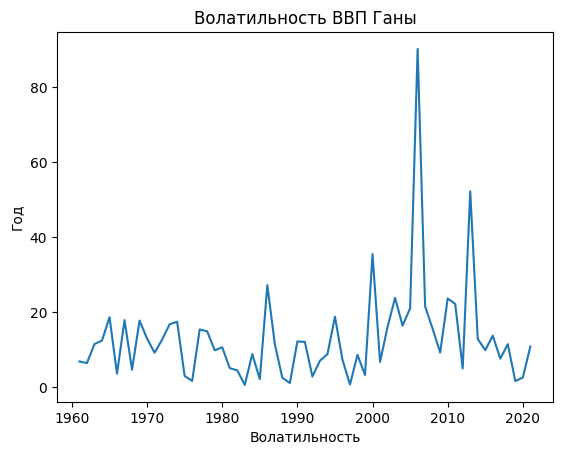

In [28]:
plt.plot(vol)
plt.title('Волатильность ВВП Ганы')
plt.xlabel('Волатильность')
plt.ylabel('Год');

2. Используйте GARCH-модель для предсказания волатильности.

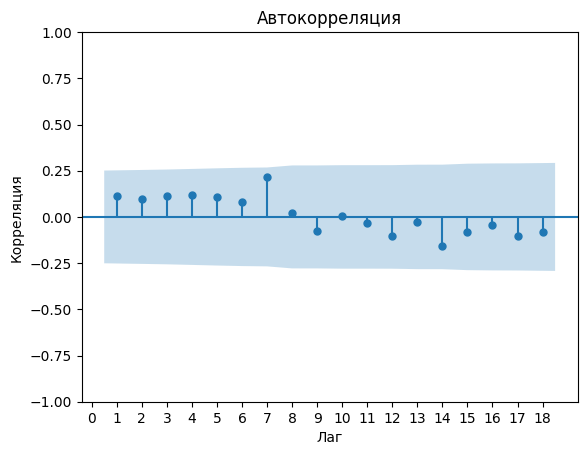

In [29]:
sgt.plot_acf(vol, zero=False)
plt.title('Автокорреляция')
plt.xlabel('Лаг')
plt.ylabel('Корреляция')
plt.xticks(range(19))
plt.show()

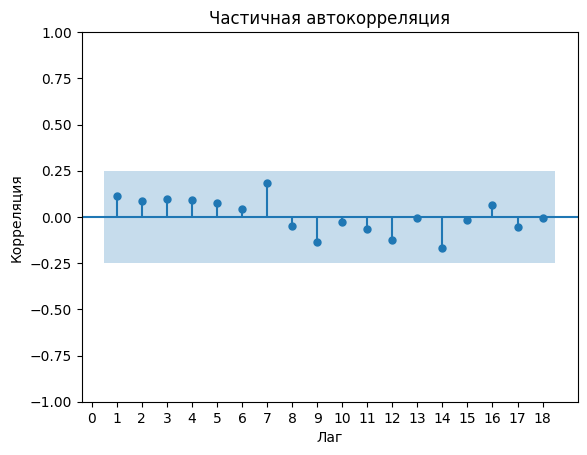

In [30]:
sgt.plot_pacf(vol, zero=False)
plt.title('Частичная автокорреляция')
plt.xlabel('Лаг')
plt.ylabel('Корреляция')
plt.xticks(range(19))
plt.show()

Выраженных лагов в данных не наблюдается

In [31]:
vol_train = vol.iloc[:-3]
vol_test = vol.iloc[-3:]

In [68]:
result = adfuller(vol)
print(f'adf: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Критические значения: {result[4]}')
if result[0] > result[4]['5%']:
    print('\nРяд нестационарный')
else:
    print('\nРяд стационарный')

adf: -6.807338944696349
p-value: 2.1599127900855016e-09
Критические значения: {'1%': -3.5443688564814813, '5%': -2.9110731481481484, '10%': -2.5931902777777776}

Ряд стационарный


In [112]:
model = arch_model(vol, vol='GARCH', p=2, q=1, mean='Constant', dist='normal')
model_results = model.fit(last_obs=vol_test.index[0], update_freq=5)
predictions_df = vol_test.copy()
predictions_df["Predictions"] = np.sqrt(model_results.forecast().residual_variance.loc[vol_test.index])
display(predictions_df)

Iteration:      5,   Func. Count:     32,   Neg. LLF: 265.1049258592761
Iteration:     10,   Func. Count:     67,   Neg. LLF: 234.36386526618477
Iteration:     15,   Func. Count:    101,   Neg. LLF: 227.1851522139178
Iteration:     20,   Func. Count:    131,   Neg. LLF: 226.59781235927204
Optimization terminated successfully    (Exit mode 0)
            Current function value: 226.59781235927204
            Iterations: 21
            Function evaluations: 136
            Gradient evaluations: 21


,GDP (current US$),Predictions
year,,
2019-01-01,1.542746,16.987063
2020-01-01,2.495937,17.094752
2021-01-01,10.780603,17.201767


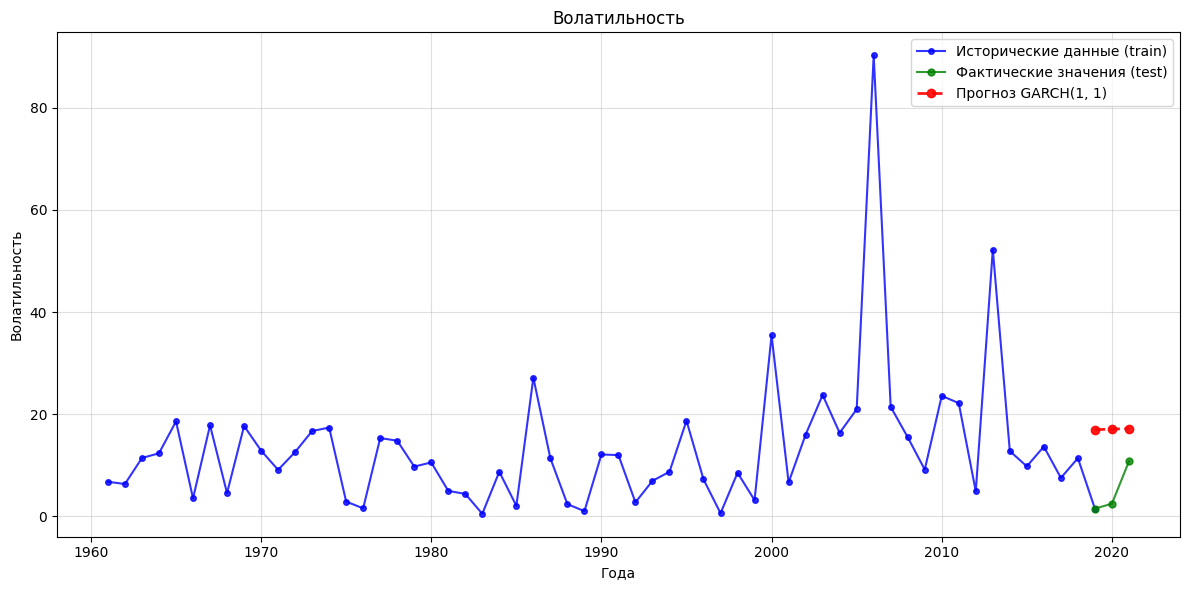

In [109]:
plt.figure(figsize=(12, 6))
plt.plot(vol[:-2], color='blue', marker='o', linestyle='-', 
         linewidth=1.5, markersize=4, label='Исторические данные (train)', alpha=0.8)

plt.plot(vol_test, color='green', marker='o', linestyle='-', 
         linewidth=1.5, markersize=5, label='Фактические значения (test)', alpha=0.8)

plt.plot(predictions_df['Predictions'], color='red', marker='o', linestyle='--', 
         linewidth=2, markersize=6, label='Прогноз GARCH(1, 1)', alpha=0.9)

plt.ylabel('Волатильность')
plt.xlabel('Года')
plt.title('Волатильность')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.legend();

In [98]:
import numpy as np
import pandas as pd
from arch import arch_model

# Ваши данные
vol = df.pct_change(1).mul(100).abs().dropna()  # абсолютные % изменения

# Правильная спецификация модели
# Для волатильности лучше использовать небольшие p и q
best_aic = np.inf
best_model = None
best_params = None

# Перебираем небольшие значения p и q
for p in [1, 2, 3]:
    for q in [1, 2, 3]:
        try:
            model = arch_model(
                vol, 
                vol='GARCH', 
                p=p, 
                q=q,
                mean='Zero',  # Среднее = 0 для абсолютных изменений
                dist='normal'
            )
            
            model_results = model.fit(
                last_obs=vol_test.index[0], 
                update_freq=5,
                disp='off'  # отключаем вывод
            )
            
            if model_results.aic < best_aic:
                best_aic = model_results.aic
                best_model = model_results
                best_params = (p, q)
                
            print(f"GARCH({p},{q}) - AIC: {model_results.aic:.2f}")
            
        except:
            print(f"GARCH({p},{q}) - ошибка")
            continue

print(f"\nЛучшая модель: GARCH{best_params} с AIC={best_aic:.2f}")

# Прогнозирование с лучшей моделью
if best_model:
    # Получаем прогноз дисперсии
    forecasts = best_model.forecast(horizon=1)
    
    # ИЗВЛЕКАЕМ КОРЕНЬ, чтобы получить волатильность (стандартное отклонение)
    predicted_variance = forecasts.variance.loc[vol_test.index]
    predicted_volatility = np.sqrt(predicted_variance)  # <-- КЛЮЧЕВОЙ МОМЕНТ!
    
    # Создаем DataFrame с результатами
    predictions_df = vol_test.copy()
    predictions_df["Predictions"] = predicted_volatility.values  # волатильность
    predictions_df["Variance"] = predicted_variance.values  # дисперсия (для сравнения)
    
    print("\nРезультаты (волатильность в %):")
    display(predictions_df)
    
    # Проверяем масштаб
    print(f"\nСреднее фактическое: {vol_test.mean()}")
    print(f"Среднее прогнозируемое: {predicted_volatility.mean()}")

GARCH(1,1) - AIC: 507.50
GARCH(1,2) - AIC: 508.77
GARCH(1,3) - AIC: 510.63
GARCH(2,1) - AIC: 508.86
GARCH(2,2) - AIC: 510.77
GARCH(2,3) - AIC: 510.31
GARCH(3,1) - AIC: 508.78
GARCH(3,2) - AIC: 509.16
GARCH(3,3) - AIC: 510.42

Лучшая модель: GARCH(1, 1) с AIC=507.50

Результаты (волатильность в %):


,GDP (current US$),Predictions,Variance
year,,,
2019-01-01,1.542746,20.851207,434.772844
2020-01-01,2.495937,19.325329,373.468359
2021-01-01,10.780603,18.567877,344.766053



Среднее фактическое: GDP (current US$)    4.939762
dtype: float64
Среднее прогнозируемое: h.1    19.581471
dtype: float64
